## Análisis de datos - Clase 3

## Medidas de asociación de variables
<hr style="border:1px solid gray">

In [46]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import chi2_contingency, kendalltau, f_oneway, pointbiserialr


#### Importamos el dataset
---


In [31]:
# Cargamos el dataset de Titanic
titanic_df = sns.load_dataset('titanic') # sns.load_dataset Devuelve un Pandas DF

#### Identificamos y ajustamos los tipos de variables

In [32]:
# Pandas no necesariamente asigna el dtype en forma correcta al importar. 
# Conviene revisar cada variable y asignar el tipo de dato correcto.

titanic_numericas = ['age', 'fare','sibsp', 'parch']
titanic_cat_nom =['survived', 'sex', 'embarked',  'who', 'deck', 'embark_town', 'alive', 'adult_male', 'alone']
titanic_cat_ord   = {
    'pclass': CategoricalDtype(categories=[1, 2, 3],                    ordered=True),
    'class':  CategoricalDtype(categories=['First', 'Second', 'Third'],  ordered=True),
}

dtype_map = {col: 'float64'  for col in titanic_numericas}  # Creamos un mapping para las numéricas
dtype_map.update({col: 'category' for col in titanic_cat_nom})  # Adicionamos el mapping para las nominales
dtype_map.update(titanic_cat_ord) # Agregamos el de las ordinales

titanic_df = titanic_df.astype(dtype_map) # Aplicamos el mapping al DataFrame

titanic_df.dtypes

survived       category
pclass         category
sex            category
age             float64
sibsp           float64
parch           float64
fare            float64
embarked       category
class          category
who            category
adult_male     category
deck           category
embark_town    category
alive          category
alone          category
dtype: object

---
---
## Cálculo de medidas de asociación
---
---

#### 1) Coeficiente Phi (binaria - binaria)

In [45]:
# Función para calcular Phi
def phi(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / n) 

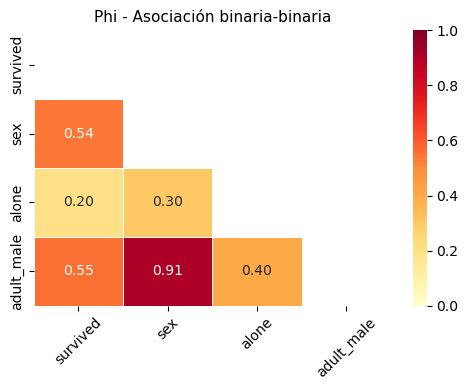

In [60]:
binarias = ['survived', 'sex', 'alone', 'adult_male']

phi_mat = pd.DataFrame(index=binarias, columns=binarias, dtype=float)

for c1 in binarias:
    for c2 in binarias:
        if c1 == c2:
            phi_mat.loc[c1, c2] = 1.0
        else:
            mask = titanic_df[c1].notna() & titanic_df[c2].notna()
            x = titanic_df.loc[mask, c1].cat.codes   # Convertir a 0/1
            y = titanic_df.loc[mask, c2].cat.codes
            phi_mat.loc[c1, c2] = phi(x, y)

# Máscara para mostrar solo la mitad inferior de la matriz
mask_upper = np.triu(np.ones_like(phi_mat, dtype=bool))

# Graficamos el heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(phi_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask_upper, ax=ax)

ax.set_title("Phi - Asociación binaria-binaria", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---

#### 2) Punto Biserial (numérica - binaria)

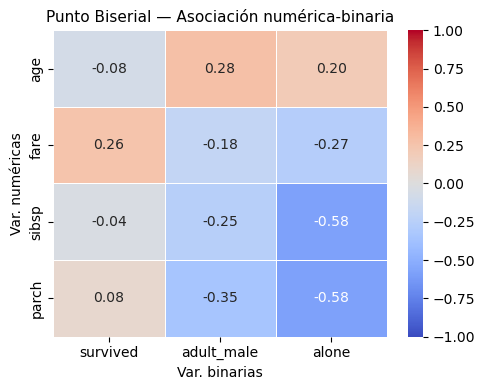

In [59]:
num_cols    = ['age', 'fare', 'sibsp', 'parch']
binary_cols = ['survived', 'adult_male', 'alone']

pb_mat = pd.DataFrame(index=num_cols, columns=binary_cols, dtype=float)

for num_col in num_cols:
    for bin_col in binary_cols:
        mask = titanic_df[num_col].notna() & titanic_df[bin_col].notna()
        num  = titanic_df.loc[mask, num_col]
        bn   = titanic_df.loc[mask, bin_col].cat.codes   # 0/1
        r, p = pointbiserialr(bn, num) # pointbiserialr Devuelve r y p-value, pero solo nos interesa r
        pb_mat.loc[num_col, bin_col] = r

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(pb_mat.astype(float), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5,
            center=0, ax=ax)

ax.set_title("Punto Biserial — Asociación numérica-binaria", fontsize=11)
ax.set_xlabel("Var. binarias")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

---

#### 3) Cramer's V (fuerza de asoc. categórica - categórica)

In [33]:
# Funcioncita para calcular Cramér's V entre dos variables categóricas x e y


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


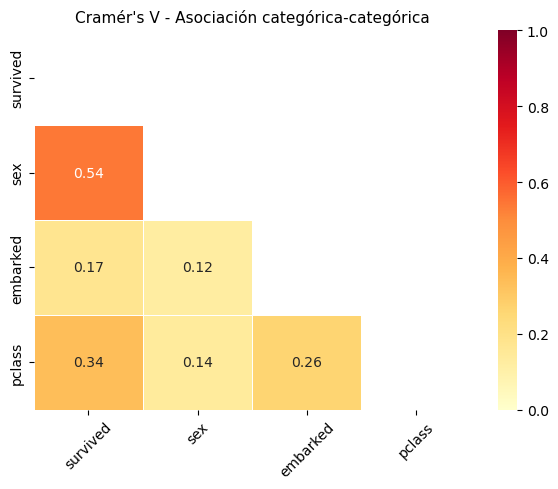

In [ ]:
cat_cols = ['survived', 'sex', 'embarked', 'pclass'] # Uso un subconjunto para que no me quede tan grande la matriz

v_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
        else:
            mask = titanic_df[c1].notna() & titanic_df[c2].notna()
            v_mat.loc[c1, c2] = cramers_v(
                titanic_df.loc[mask, c1], titanic_df.loc[mask, c2]
            )


# Máscara para mostrar solo la mitad inferior de la matriz
mask = np.triu(np.ones_like(v_mat, dtype=bool))

# Dibujamos la matriz con heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask, ax=ax)

ax.set_title("Cramér's V - Fuerza de asociación categórica-categórica", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


---

#### 4) Kendall Tau-B (numérica - categórica ordinal)

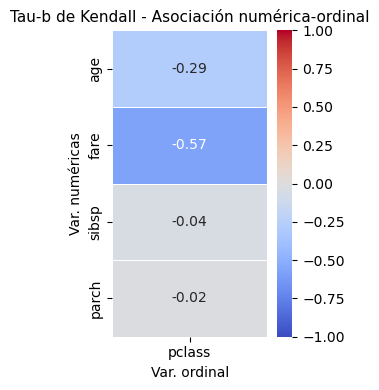

In [58]:

num_cols = ['age', 'fare', 'sibsp', 'parch']
ord_cols = ['pclass'] # Solo uso esta porque la otra es redundante

results_tau = {}
for num_col in num_cols:
    for ord_col in ord_cols:
        mask = titanic_df[num_col].notna() & titanic_df[ord_col].notna()
        s1   = titanic_df.loc[mask, num_col]
        s2   = titanic_df.loc[mask, ord_col].cat.codes  # convert ordered cat to int
        tau, p = kendalltau(s1, s2, variant='b') # por defecto es tau-b pero se puede cambiar
        results_tau[(num_col, ord_col)] = tau

# Calculamos la matriz de resultados
tau_mat = pd.DataFrame(
    {ord_col: {num: results_tau[(num, ord_col)] for num in num_cols}
     for ord_col in ord_cols}
)

# Heatmap
fig, ax = plt.subplots(figsize=(3, 4))
sns.heatmap(tau_mat, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5,
            center=0, ax=ax)

ax.set_title("Tau-b de Kendall - Asociación numérica-ordinal", fontsize=11)
ax.set_xlabel("Var. ordinal")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

---

#### 5) Eta cuadrado (numérica - categórica)

In [36]:
def eta_squared(continuous, categorical):
    mask       = continuous.notna() & categorical.notna()
    y, grp     = continuous[mask], categorical[mask]
    groups     = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p       = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total   = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F

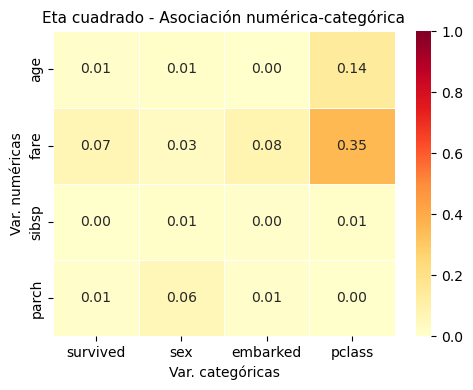

In [57]:

num_cols = ['age', 'fare', 'sibsp', 'parch']
cat_cols = ['survived', 'sex', 'embarked', 'pclass'] # Uso un subconjunto para simplificar

resultados = {}
for num_col in num_cols:
    for cat_col in cat_cols:
        eta2, p, F = eta_squared(titanic_df[num_col], titanic_df[cat_col])
        resultados[(num_col, cat_col)] = eta2

# Armamos la matriz de resultados
eta2_mat = pd.DataFrame(
    {cat: {num: resultados[(num, cat)] for num in num_cols} for cat in cat_cols}
)

# Dibujamos el heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Eta cuadrado - Asociación numérica-categórica", fontsize=11)
ax.set_xlabel("Var. categóricas")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()